#**ANALISI DEI DISASTRI AEREI DAL 1919 AL 2023**

In questo notebook viene utilizzato un file CSV contenente diverse informazioni sugli incidenti aerei avvenuti tra il 1919 e il 2023.<br>

I dati saranno analizzati per ricavare insight utili.<br>

L'analisi verrà suddivisa in sezioni per facilitare la lettura e la comprensione dei vari insight.

In [1]:
# Installazione di country_converter per uniformare "country"
!pip install country-converter

# Importazione librerie necessarie
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colormaps
import country_converter as coco
import plotly.express as px

# Configurazione dimensioni dei grafici
plt.rcParams["figure.figsize"]=[10, 6]

# Importazione CSV direttamente da URL e copia per evitare di modificare l'originale
df_raw = pd.read_csv("https://proai-datasets.s3.eu-west-3.amazonaws.com/aviation-accidents.csv")
df = df_raw.copy()

# Istanza a singolo oggetto CountryConverter
cc = coco.CountryConverter()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.5/47.5 kB 2.4 MB/s eta 0:00:00


##**1. Sezione: Esplorazione dati**

Per capire com'è composto e strutturato il dataset per eventuale pulizia

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23967 entries, 0 to 23966
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   date          23967 non-null  object
 1   type          23967 non-null  object
 2   registration  22419 non-null  object
 3   operator      23963 non-null  object
 4   fatalities    20029 non-null  object
 5   location      23019 non-null  object
 6   country       23967 non-null  object
 7   cat           23967 non-null  object
 8   year          23967 non-null  object
dtypes: object(9)
memory usage: 1.6+ MB


In [ ]:
df

,date,type,registration,operator,fatalities,location,country,cat,year
0,date unk.,Antonov An-12B,T-1206,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
1,date unk.,Antonov An-12B,T-1204,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
2,date unk.,Antonov An-12B,T-1201,Indonesian AF,NaN,NaN,Unknown country,U1,unknown
3,date unk.,Antonov An-12BK,NaN,Soviet AF,NaN,Tiksi Airport (IKS),Russia,A1,unknown
4,date unk.,Antonov An-12BP,CCCP-11815,Soviet AF,0,Massawa Airport ...,Eritrea,A1,unknown
...,...,...,...,...,...,...,...,...,...
23962,11-MAY-2023,Hawker 900XP,PK-LRU,Angkasa Super Services,0,Maleo Airport (MOH),Indonesia,A2,2023
23963,11-MAY-2023,Cessna 208B Grand Caravan,PK-NGA,Nasional Global Aviasi,0,Fentheik Airstrip,Indonesia,A2,2023
23964,12-MAY-2023,Cessna 208B Grand Caravan,5X-RBR,Bar Aviation,0,Kampala-Kajjansi...,Uganda,A1,2023
23965,14-MAY-2023,Boeing 747-4R7F,LX-OCV,Cargolux,0,Luxembourg-Finde...,Luxembourg,A2,2023


### Approfondimenti

Da una prima esplorazione sono presenti valori nulli e tutti gli elementi sono di tipo 'object'. Risulta quindi necessario un approfondimento sui valori nulli e una successiva conversione e pulizia dei dati.

In [ ]:
# Conteggio dei valori nulli per ogni colonna
df.isnull().sum()

,0
date,0
type,0
registration,1548
operator,4
fatalities,3938
location,948
country,0
cat,0
year,0


In [ ]:
# Controllo degli elementi unici per verificare eventuali incongruenze
for col in df.columns:
  print(col, df[col].unique())

date ['date unk.' '02-AUG-1919' '11-AUG-1919' ... '12-MAY-2023' '14-MAY-2023'
 '15-MAY-2023']
type ['Antonov An-12B' 'Antonov An-12BK' 'Antonov An-12BP' ...
 'Antonov An-72-100D' 'Boeing 737-33A (SF)' 'Boeing 777-233LR']
registration ['T-1206' 'T-1204' 'T-1201' ... 'PK-NGA' '5X-RBR' 'D-CGFQ']
operator ['Indonesian AF' 'Soviet AF' 'GUSMP, Directorate of Polar Aviation' ...
 'Angkasa Super Services' 'Nasional Global Aviasi' 'Bar Aviation']
fatalities [nan '0' '14' '1' '4' '2' '5' '6' '3' '7' '5+ 1' '8' '16' '12' '9' '15'
 '14+ 1' '10' '11' '35+ 9' '13' '2+ 2' '17' '19' '20' '0+ 1' '18' '13+ 1'
 '25' '29' '23' '5+ 7' '24' '36' '26' '22' '27' '12+ 1' '21' '7+ 6' '35'
 '32' '31' '2+ 1' '34' '28' '20+ 5' '0+ 2' '30' '41' '59' '13+ 7' '45'
 '44' '37' '3+ 5' '4+ 6' '30+ 1' '19+ 1' '39' '11+ 1' '43' '53' '0+ 3'
 '50' '14+ 3' '3+ 1' '52' '8+ 1' '5+ 3' '40' '0+ 6' '8+ 2' '33' '48' '55'
 '1+ 1' '38' '0+ 7' '32+ 1' '13+ 2' '80' '1+ 2' '46' '58' '51' '10+ 3'
 '56' '23+ 7' '29+ 4' '2+ 3' '5+ 2' '87' 

##**2. Sezione: Pulizia dati**

Conversioni necessarie, sistemazione caratteri mal letti, gestione valori nulli, ecc.

**Note:** i valori nulli all'interno del DataFrame non sono stati sostituiti in quanto, trattandosi di incidenti e persone decedute (dati storici reali), non trovo corretto imputare valori statistici. Ho quindi preferito lasciare NaN per i valori numerici e "unknown" per i valori categorici, data la bassa percentuale < 20%, in modo da escluderli dalle analisi o considerarli un gruppo a parte.<br>

Ho deciso di rimuovere la colonna "location" in quanto presenta incompletezze, approssimazioni di località o comunque non standardizzate a livello globale e quindi non utilizzabile né per estrapolare una possibile "country" mancante né per una corretta analisi.<br>

Ho deciso di rimuovere anche la colonna "registration" in quanto è altamente specifica per ogni velivo e non contribuisce all'analisi.

Ho standardizzato la colonna "country" tramite la libreria country_convert, che permette di converterire automaticamente eventuali abbreviazioni e varianti non standard all'interno del DF in codici ISO3 (per l'utilizzo in cartogramma) e nomi puliti, ovvero normalizzati per ogni Nazione (per l'utilizzo in analisi e grafici).

In [2]:
# Rimozione colonne "location" e "registration"
df = df.drop(["location", "registration"], axis=1)

In [3]:
# Ricodifica di caratteri corrotti nel DF
df = df.applymap(lambda x: x.encode("latin1", "ignore").decode(
    "utf-8", "ignore") if isinstance(x, str) else x)

/tmp/ipykernel_10693/3422498054.py:2: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df = df.applymap(lambda x: x.encode("latin1", "ignore").decode(


In [4]:
# Conversione colonna "date" in datetime
df["date"] = pd.to_datetime(df["date"].replace("date unk.", pd.NA), errors="coerce")

# Conversione colonna "year"
df["year"] = pd.to_numeric(df["year"].replace("unknown", pd.NA), errors="coerce").astype("Int64")

# Gestione colonna "fatalities": conversione a numeri interi e somma quando presente "+"
df["fatalities"] = pd.to_numeric(df["fatalities"].apply(
    lambda x: eval(x.replace(" ", "")) if isinstance(x, str) and "+" in x else x)).astype("Int64")

# Rimozione di eventuali virgole/spazi exta da colonne categoriche
cols_str = df.select_dtypes(include="object").columns
for col in cols_str:
  df[col] = df[col].str.lstrip(", ").str.strip()

# Sostituzione dei valori mancanti con "unknown" e normalizzazione testo in maiuscolo nella colonna "operator"
df["operator"] = df["operator"].fillna("unknown")
df["operator"] = df["operator"].str.upper()

# Standardizzazione colonna "country"
fix_country = {"C.A.R.": "Central African Republic", "D.R. Congo": "Democratic Republic of the Congo",
    "B.V.I.": "British Virgin Islands", "U.S. M.O. Islands": "United States Minor Outlying Islands",
    "Timor": "Timor-Leste", "Caribbean Neth'lands": "Caribbean Netherlands"}

df["country"] = df["country"].replace(["?", "", " ", None], "Unknown country")

df["country"] = df["country"].replace(fix_country)

df["country_iso3"] = cc.pandas_convert(series=df["country"], to="ISO3")
df["country_clean"] = cc.pandas_convert(series=df["country"], to="name_short", not_found=None)

/tmp/ipykernel_10693/3567879633.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["date"] = pd.to_datetime(df["date"].replace("date unk.", pd.NA), errors="coerce")


##**3. Sezione: Analisi e visualizzazioni**

####**3.1 Analisi temporale degli incidenti**

**_Analisi annuale_**

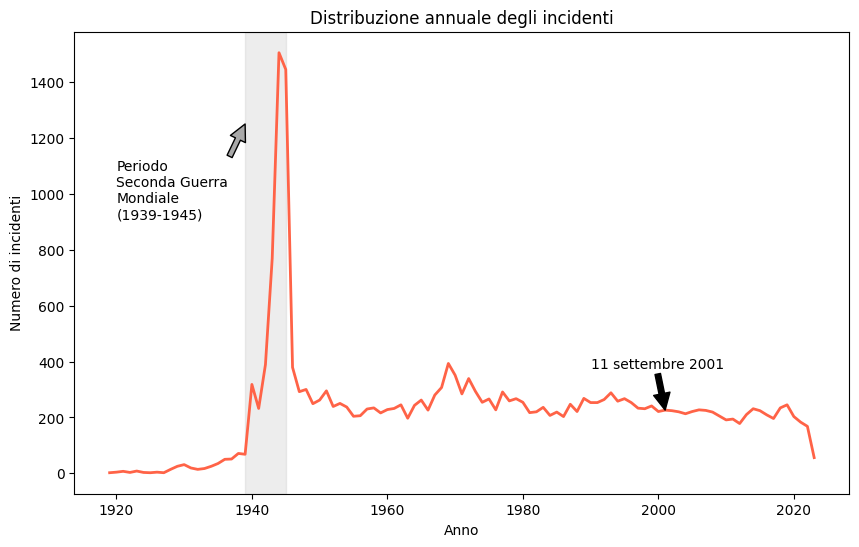

In [ ]:
# Calcolo degli incidenti per anno
year_accidents = df["year"].value_counts().sort_index()

# Distribuzione annuale degli incidenti
year_accidents_plot = plt.plot(year_accidents.index, year_accidents.values,
                               color="tomato", linewidth=2)

plt.title("Distribuzione annuale degli incidenti")
plt.xlabel("Anno")
plt.ylabel("Numero di incidenti")

# Evidenziazione Seconda Guerra Mondiale (1939-1945)
plt.axvspan(1939, 1945, color="darkgray", alpha=0.2)
plt.annotate("Periodo\nSeconda Guerra\nMondiale\n(1939-1945)",
            xy=(1939, 1250),
            xytext=(1920, 900),
            ha="left",
            va="bottom",
            fontsize=10,
            arrowprops=dict(facecolor="darkgray"))

# Annotazione 11-09-2001
if 2001 in year_accidents.index:
  year_2001 = year_accidents.loc[2001]
  plt.annotate("11 settembre 2001",
              xy=(2001, year_2001),
              xytext=(1990, year_2001 + 150),
              arrowprops=dict(facecolor="black"))

plt.show()

**Commento**: L'impennata anomala degli incidenti negli anni '40 coincide con la Seconda Guerra Mondiale (1939-1945).<br>
Il periodo è stato quindi caratterizzato da un traffico aereo militare maggiore, e le condizioni operative erano estreme e con una manutenzione aerea spesso ridotta. Queste condizioni hanno influito sull'aumento esponenziale degli incidenti.<br>
Si può invece notare che negli ultimi anni, dal 2019-2020 circa, gli incidenti aerei sono sempre più in diminuzione.

**_Focus 11 settembre 2001_**

**Nota**: L'analisi viene effettuata sulla variabile "date" considerando il periodo 1990-2023. Anche se in quest'arco temporale circa l'1.8% degli incidenti presenti nel dataset dispone di una data parziale (mese e/o giorno mancanti), l'analisi può essere condotta solo sui record con data completa, garantendo comunque l'affidabilità dei risultati.

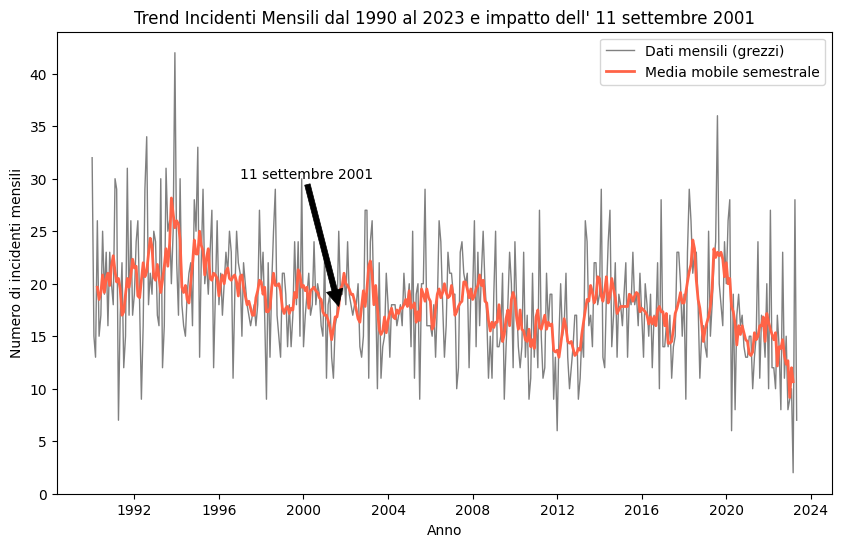

In [ ]:
# DF filtrato dal 1990 al 2023 per date valide
mask_1990_2023 = (df["year"].between(1990, 2023)) & (df["date"].notna())
df_focus = df.loc[mask_1990_2023].copy()

# Creazione colonna con mese e anno (senza il giorno)
df_focus["month_year"] = df_focus["date"].dt.to_period("M").dt.to_timestamp()

# Raggruppamento degli incidenti mensili
month_accidents = df_focus.groupby("month_year").size()

# Calcolo media mobile semestrale
month_accidents_ma = month_accidents.rolling(window=6, center=True).mean()

# Creazione grafico
plt.plot(month_accidents.index, month_accidents.values, color="gray", linewidth=1,
         label="Dati mensili (grezzi)")
plt.plot(month_accidents_ma.index, month_accidents_ma.values, color="tomato",
         linewidth=2, label="Media mobile semestrale")

plt.title("Trend Incidenti Mensili dal 1990 al 2023 e impatto dell' 11 settembre 2001")
plt.xlabel("Anno")
plt.ylabel("Numero di incidenti mensili")

# Annotazione 11-09-2001 (prendendo in considerazione solo mesi e anni, no giorni, la data viene automaticamente considerata al giorno 01)
data_11 = pd.Timestamp("2001-09-01")

plt.annotate("11 settembre 2001",
            xy=(data_11, month_accidents_ma.loc[data_11]),
            xytext=(pd.Timestamp("1997-01-01"), 30),
            arrowprops=dict(color="black", linewidth=0.5))

plt.legend()
plt.show()

**Commento**: L'analisi temporale mostra che, nel complesso, il numero di incidenti non ha subito variazioni significative dopo l'11 settembre 2001.<br>
Tuttavia, questo tipo di valutazione non è sufficiente per comprendere l'impatto che può aver avuto questo evento.<br>
Per farlo è necessario analizzare anche le categorie degli incidenti, così da verificare se siano cambiate le tipologie di incidenti.<br>

Quest'analisi permette di capire se l'11 settembre abbia influenzato la natura degli incidenti più che la loro quantità.

**_Approfondimento sull'evoluzione delle categorie di incidenti collegate a criminalità/terrorismo prima e dopo l'11 settembre 2001 (periodo 1990-2023)_**

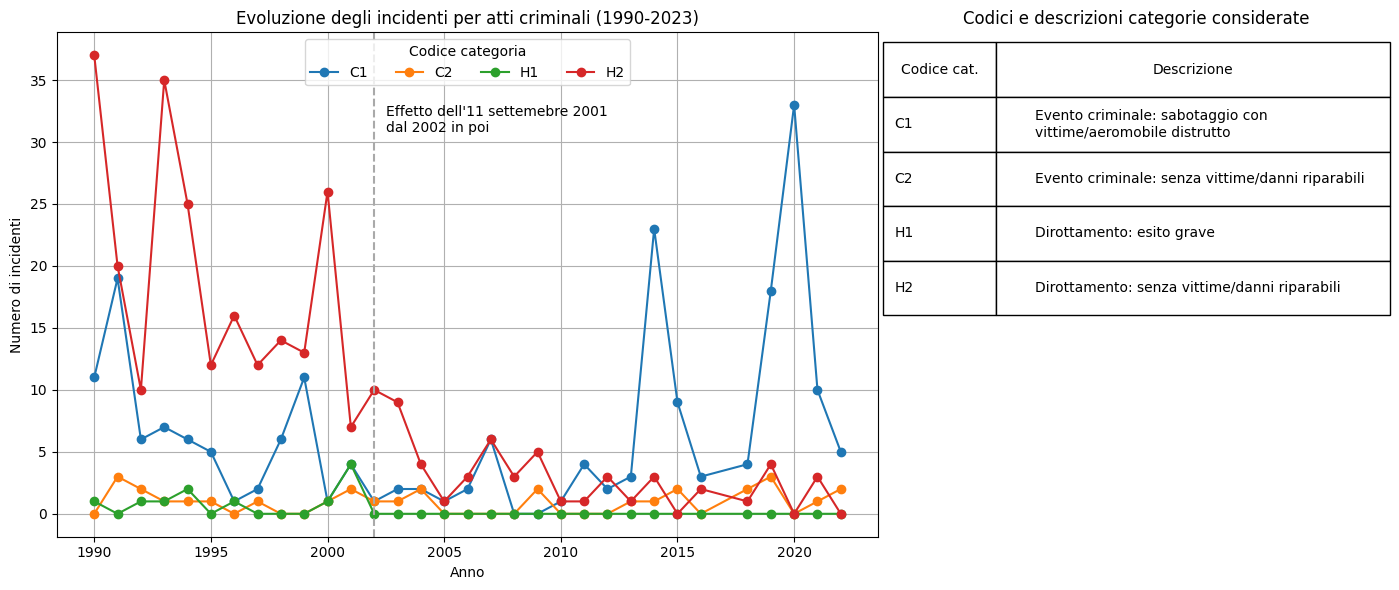

In [ ]:
# Creazione colonna con descrizione italiana attraverso mappatura dei codici di categoria per il periodo 1990-2023
cat_map_it = {"A1": "Incidente: grave con vittime/aeromobile distrutto",
              "A2": "Incidente: senza vittime/danni riparabili",
              "C1": "Evento criminale: sabotaggio con\nvittime/aeromobile distrutto",
              "C2": "Evento criminale: senza vittime/danni riparabili",
              "H1": "Dirottamento: esito grave",
              "H2": "Dirottamento: senza vittime/danni riparabili",
              "I1": "Incidente: con danni significativi",
              "I2": "Incidente minore: senza danni significativi",
              "O1": "Altro tipo di evento con esito grave",
              "O2": "Altro tipo di evento con esito meno grave",
              "U1": "Evento non classificato o con dati insufficienti"}
df_focus["cat_desc_it"] = df_focus["cat"].map(cat_map_it)

# Selezione delle categorie da considerare
cat_select = ["C1", "C2", "H1", "H2"]

df_cat = df_focus[df_focus["cat"].isin(cat_select)]

# Calcolo degli incidenti per anno e categoria
cat_by_year = df_cat.groupby(["year", "cat"]).size().unstack(fill_value=0)

# Dimensioni figura che contiene grafico e tabella
plt.figure(figsize=(14, 6))

# Creazione grafico
plt.subplot(1, 3, (1, 2))

for cat in cat_select:
  plt.plot(cat_by_year.index, cat_by_year[cat], marker="o", label=cat)

plt.axvline(x=2002, linestyle="--", color="darkgray", linewidth=1.5)
plt.text(2002.5, 33, "Effetto dell'11 settemebre 2001\ndal 2002 in poi", va="top")

plt.title("Evoluzione degli incidenti per atti criminali (1990-2023)")
plt.xlabel("Anno")
plt.ylabel("Numero di incidenti")

plt.legend(title="Codice categoria", ncol=4, loc="upper center")
plt.grid()

# Creazione tabella di corripondenza codice "cat" -> descrizione in italiano
plt.subplot(1, 3, 3)

table_data = df_cat[["cat", "cat_desc_it"]].drop_duplicates().sort_values("cat")

table = plt.table(cellText=table_data.values, colLabels=["Codice cat.", "Descrizione"],
                  loc="upper center", cellLoc="left", colWidths=[0.2, 0.7])

table.scale(1.5, 3)
table.auto_set_font_size(False)
table.set_fontsize(10)

plt.title("Codici e descrizioni categorie considerate")
plt.axis("off")

plt.tight_layout()
plt.show()

**Commento**: In linea generale, dopo l'evento dell'11 settemebre 2001, sono diminuiti i dirottamenti:
- quelli più gravi (H1) non si sono più verificati;
- quelli con esiti senza vittime/danni riparabili (H2) si sono ridotti drasticamente.

Gli eventi criminali, invece, hanno andamenti diversi:
- quelli più gravi (C1) si sono verificati in modo molto variabile nel tempo, con forti aumenti e diminuzioni dal 2014 al 2023;
- quelli con esiti senza vittime/danni riparabili (C2) si sono generalmente verificati meno rispetto alle altre categorie.

In sintesi, seppur con andamenti irregolari e differenze tra le categorie, dopo il 2001 gli eventi dovuto ad atti criminali/terrostici risultano meno frequenti e meno estremi rispetto al periodo precedente.

**_Frequenza media degli incidenti per i diversi giorni della settimana_**

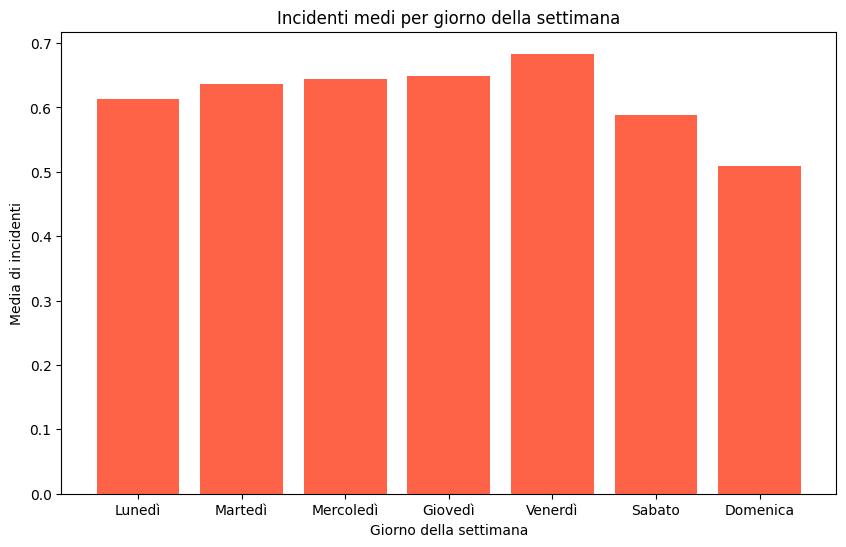

In [ ]:
# Estrazione in nuova colonna dei giorni della settimane dalle date
df["weekday"] = df["date"].dt.day_name()

# Lista ordinata dei giorni della settimana
weekdays_list = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekdays_it = ["Lunedì", "Martedì", "Mercoledì", "Giovedì", "Venerdì", "Sabato", "Domenica"]

# Conteggio degli incidenti per ogni giorno della settimana
weekday_accidents = df["weekday"].value_counts().reindex(weekdays_list)

# Creazione DF calendario per il calcolo della media
start_date = df["date"].min()
end_date = df["date"].max()

calendar = pd.date_range(start=start_date, end=end_date, freq="D")

df_calendar = pd.DataFrame(calendar, columns=["date"])
df_calendar["weekday"] = df_calendar["date"].dt.day_name()

# Conteggio totale di ogni giorno della settimana nell'arco temporale del dataset
day_counts = df_calendar["weekday"].value_counts().reindex(weekdays_list)

# Calcolo media di incedenti per giorno della settimana
mean_day_accidents = weekday_accidents / day_counts

# Creazione grafico
plt.bar(weekdays_it, mean_day_accidents.values, color="tomato")

plt.title("Incidenti medi per giorno della settimana")
plt.xlabel("Giorno della settimana")
plt.ylabel("Media di incidenti")

plt.show()

**Commento**: la media di incidenti per giorni della settimana risulta molto simile tra tutti i giorni, con variazioni minime che non indicano un pattern significativo. Il venerdì mostra valori leggermente più alti, mentre la domenica valori leggermente più bassi, ma le differenze rispetto agli altri giorni sono troppo piccole per suggerire delle reali tendenze.

####**3.2 Analisi delle vittime**

**_Trend annuale delle vittime_**

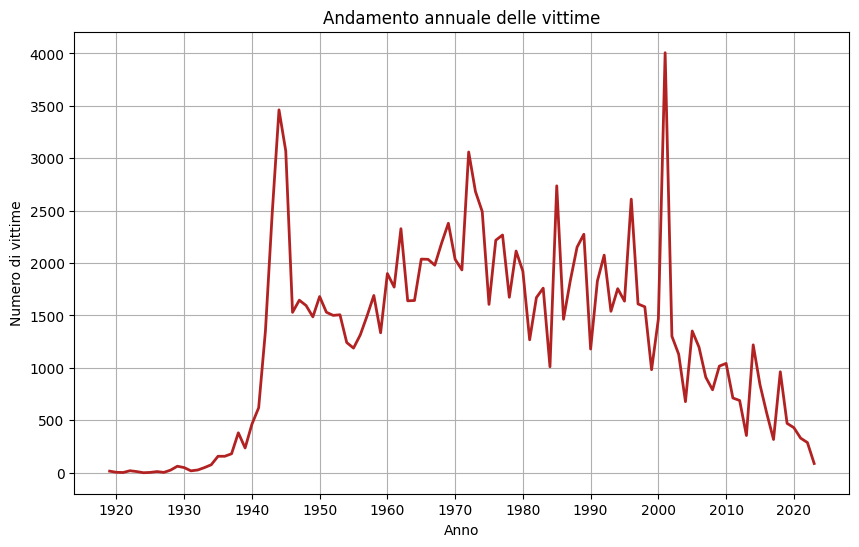

In [ ]:
# Calcolo delle vittime totali per anno
fatalities_year = df.groupby("year")["fatalities"].sum()

# Creazione grafico
plt.plot(fatalities_year.index, fatalities_year.values, color="firebrick", linewidth=2)

plt.title("Andamento annuale delle vittime")
plt.xlabel("Anno")
plt.ylabel("Numero di vittime")
plt.xticks(range(1920, 2025, 10))
plt.grid()

plt.show()

**Commento**: L'andamento delle vittime mostra due picchi molto evidenti e facilmente interpretabili:
- anni '40: gli anni della Seconda Guerra Mondiale
- 2001: anno dell'attentato alle Torri Gemelle che ha portato un numero elevato di vittime.

Esclusi questi eventi straordinari, il grafico mostra un andamento irregolare fino ai primi anni 2000, a cui segue un trend generalmente decrescente.<br>
Questo calo è coerente con il miglioramento progressivo delle tecnologie e delle procedure di sicurezza.

**_Relazione tra incidenti e vittime per anno_**

**Nota**: Per facilitare la lettura del grafico ho suddiviso gli anni in periodi ventennali, per differenziare colori e simboli dei punti, ma ogni punto sul grafico corrisponde ad un anno; alcuni periodi includono anni non prensenti nel dataset, ma questo non preclude l'analisi.

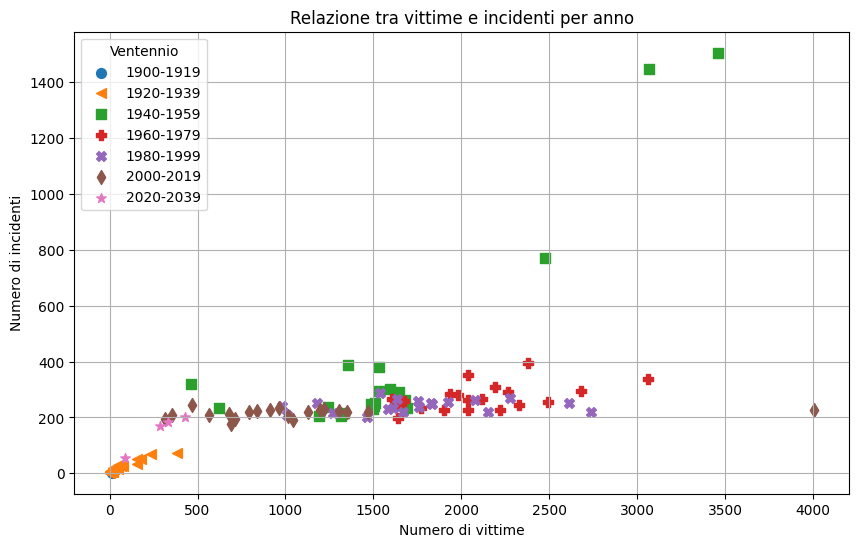

In [ ]:
# Divisione degli anni in periodi ventennali per colori e markers
periods = (df.groupby("year")["year"].first().apply(lambda x: (x // 20)*20))

markers = ["o", "<", "s", "P", "X", "d", "*"]

# Creazione scatterplot
for i, period in enumerate(sorted(periods.unique())):
  mask_p = periods == period

  plt.scatter(fatalities_year[mask_p], year_accidents[mask_p], marker=markers[i % len(markers)],
              s=50, label=f"{period}-{period+19}")

plt.title("Relazione tra vittime e incidenti per anno")
plt.xlabel("Numero di vittime")
plt.ylabel("Numero di incidenti")
plt.legend(title="Ventennio")

plt.grid()
plt.show()

**Commento**: Il grafico mostra la relazione tra numero di incidenti e numero di vittime su base annua, evidenziando come anni appartenenti a periodi storici diversi presentino combinazioni differenti tra frequenza degli incidenti e gravità delle conseguenze. In particolare, si osservano anni con un numero relativamente contenuto di incidenti ma con un elevato numero di vittime, a conferma che la gravità degli eventi non è direttamente proporzionale alla loro frequenza.

####**3.3 Analisi degli incidenti per Nazione**

**_Nazione con più incidenti in assoluto_**

In [5]:
# DF filtrato solo per Paesi validi (no sconosciuti, no mari/oceani)
df_country = df[df["country_iso3"] != "not found"]

# Conteggio degli incidenti per Nazione
country_accidents = df_country["country_clean"].value_counts()

# Nazione con più incidenti
top_country = country_accidents.idxmax()
top_val_country = country_accidents.max()

print(f"La nazione con più incidenti è {top_country} con {top_val_country} incidenti.")

La nazione con più incidenti è United States con 4377 incidenti.


**_Prime 10 Nazioni con più incidenti_**

**Nota**: Dall'analisi sono esclusi Mari/Oceani e le indicazioni "Unknown country" (Nazione sconosciuta).

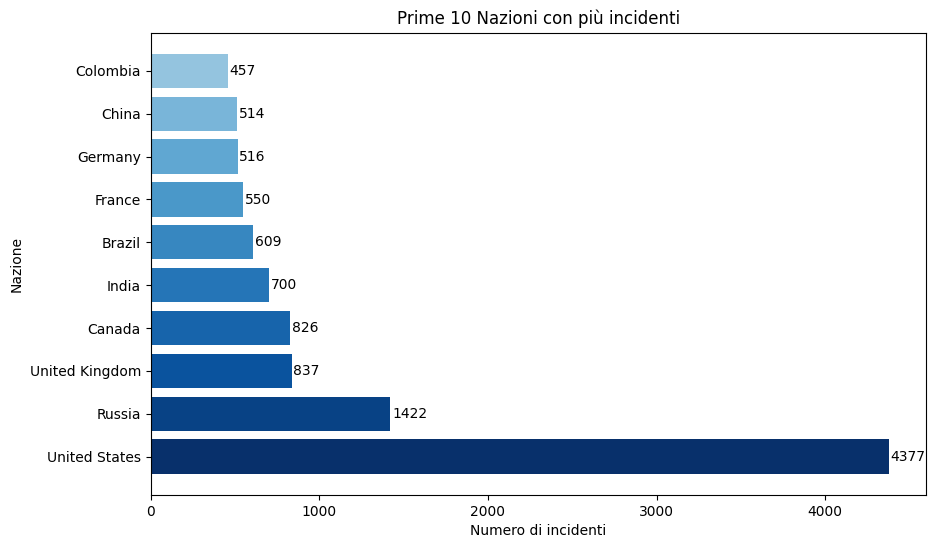

In [6]:
# Creazione grafico a barre con scala colore sequenziale
data_chart_country = country_accidents.head(10)
cmap = colormaps["Blues"]
colors = [cmap(i) for i in np.linspace(1, 0.4, len(data_chart_country))]

bars = plt.barh(data_chart_country.index, data_chart_country.values, color=colors)

plt.title("Prime 10 Nazioni con più incidenti")
plt.xlabel("Numero di incidenti")
plt.ylabel("Nazione")

for bar in bars:
  width = bar.get_width()
  plt.text(width + 10, bar.get_y() + bar.get_height() / 2, str(int(width)), va="center")

plt.show()

**Commento**: L'analisi degli incedenti per Nazione evidenzia gli Stati Uniti come la Nazione che ha avuto più incidenti dal 1919 al 2023.<br>
Il grafico a barre mostra le 10 Nazioni che hanno avuto più incidenti in quest'arco temporale.<br>

**_Cartogramma degli incidenti_**

In [ ]:
# Creazione DF per cartogramma con nomi normalizzati delle Nazioni e relativi incidenti
map_data = df_country.groupby(["country_iso3", "country_clean"]).size().reset_index(name="accidents")

# Creazione del cartogramma
fig_map = px.choropleth(map_data,
                        locations="country_iso3",
                        color="accidents",
                        hover_name="country_clean",
                        color_continuous_scale="PuOr",
                        projection="natural earth")

fig_map.update_traces(reversescale=True)

fig_map.update_layout(title={"text": "<b>Mappa globale degli incidenti aerei (1919-2023)<b>",
                             "x": 0.5,
                             "xanchor": "center",
                             "yanchor": "top"},
                      titlefont=dict(size=18, color="black"),
                      width=900,
                      coloraxis_colorbar=dict(title="N° incidenti"))


fig_map.show()

**_Analisi Mari/Oceani_**

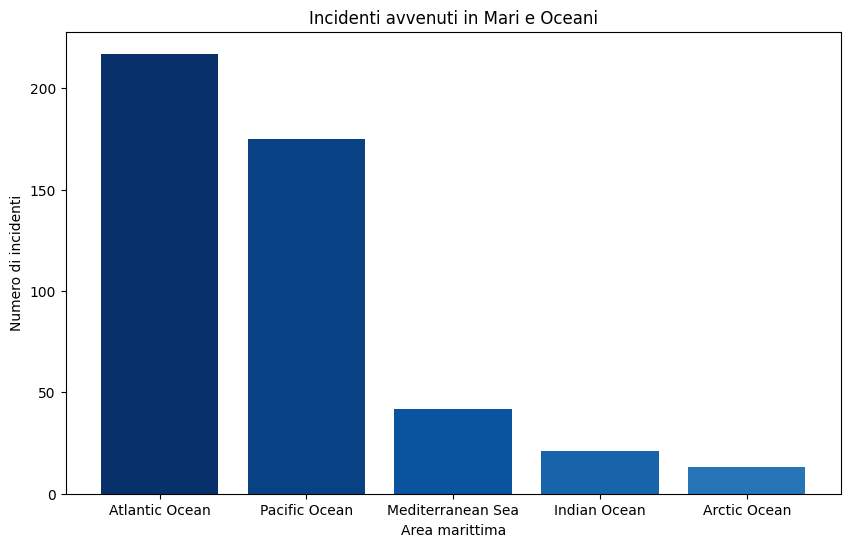

In [ ]:
# Filtro solo per mari/oceani (per semplificare verrà usata solo la parola "sea")
sea_mask = (df["country_iso3"] == "not found") & (df["country_clean"] != "Unknown country")
df_sea_accidents = df[sea_mask]

# Conteggio degli incidenti nei mari/oceani
sea_accidents_count = df_sea_accidents["country_clean"].value_counts()

# Creazione del grafico a barre
plt.bar(sea_accidents_count.index, sea_accidents_count.values, color=colors)

plt.title("Incidenti avvenuti in Mari e Oceani")
plt.xlabel("Area marittima")
plt.ylabel("Numero di incidenti")

plt.show()

**Commento**: Gli incidenti avvenuti in aree marittime rappresentano una parte ridotta del totale, ma è interessante notare come la concentrazione maggiore  si rifletta negli Oceani attraversati dalle principali rotte intercontinentali: Atlantico e Pacifico.

####**3.4 Analisi operatori e velivoli**

**_Analisi comparativa sulla gravità degli incidenti per operatore_**

**Nota**: Poiché il dataset non contiene informazioni sul numero totale dei voli effettuati da ciascun operatore, non è possibile valutarne la sicurezza in termini assoluti. L'analisi confronta quindi gli operatori in base alla relazione tra numero di incidenti e vittime medie per incidente.

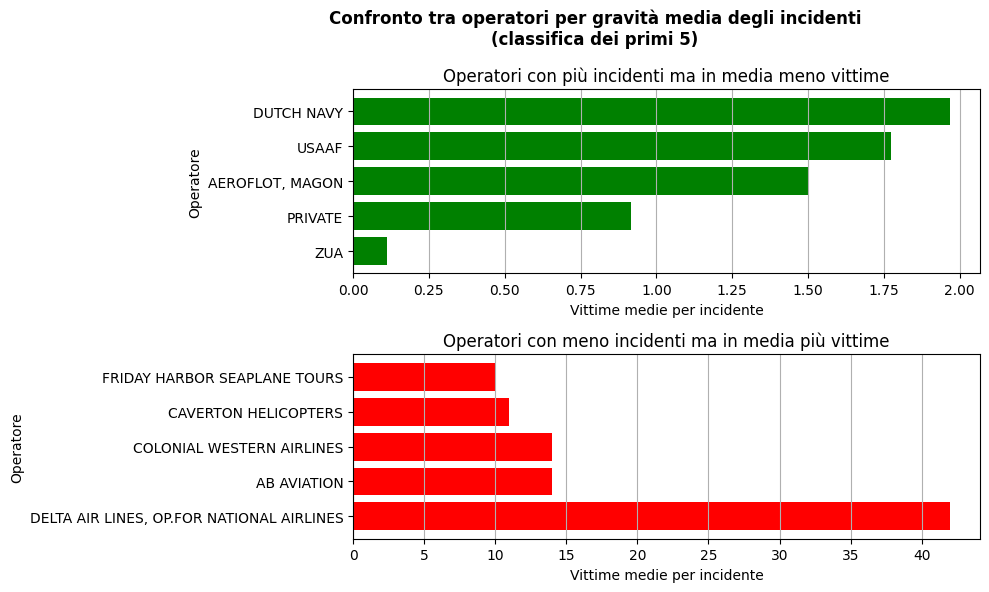

In [ ]:
# Conteggio del numero di incidenti per ogni operatore
opr_accidents = df["operator"].value_counts()
opr_accidents = opr_accidents[opr_accidents.index != "UNKNOWN"]

# Numero totale di vittime per ogni operatore
opr_fatalities = df.groupby("operator")["fatalities"].sum()
opr_fatalities = opr_fatalities[opr_fatalities.index != "UNKNOWN"]

# Calcolo media delle vittime per ogni incidente
opr_fatal_mean = opr_fatalities / opr_accidents

# Calcolo 5 operatori con più incidenti ma in media meno vittime
opr_more_accidents = opr_accidents.sort_values(ascending=False).head(100)
opr_low_fatal = opr_fatal_mean.loc[opr_more_accidents.index].sort_values().head(5)

# Calcolo 5 opertori con meno incidenti ma in media più vittime
opr_less_accidents = opr_accidents.sort_values().head(100)
opr_more_fatal = opr_fatal_mean.loc[opr_less_accidents.index].sort_values(ascending=False).head(5)

# Creazione figura
plt.suptitle("Confronto tra operatori per gravità media degli incidenti\n(classifica dei primi 5)", fontsize=12, fontweight="bold", x=0.6)

# Grafico 1: più incidenti - meno vittime
plt.subplot(2, 1, 1)

plt.barh(opr_low_fatal.index, opr_low_fatal.values, color="green")

plt.title("Operatori con più incidenti ma in media meno vittime")
plt.xlabel("Vittime medie per incidente")
plt.ylabel("Operatore")
plt.grid(axis="x")

# Grafico 2: meno incidenti - più vittime
plt.subplot(2, 1, 2)

plt.barh(opr_more_fatal.index, opr_more_fatal.values, color="red")

plt.title("Operatori con meno incidenti ma in media più vittime")
plt.xlabel("Vittime medie per incidente")
plt.ylabel("Operatore")
plt.grid(axis="x")

plt.tight_layout()
plt.show()

**Commento**: Non è possibile determinare quale sia l'operatore più sicuro; tuttavia, dai grafici emerge come alcuni operatori, pur avendo registrato pochi incidenti, abbiano avuto conseguenze mediamente più gravi, mentre altri, con un numero maggiore di incidenti, presentano una severità media inferiore.

**_Analisi delle vittime per velivolo_**

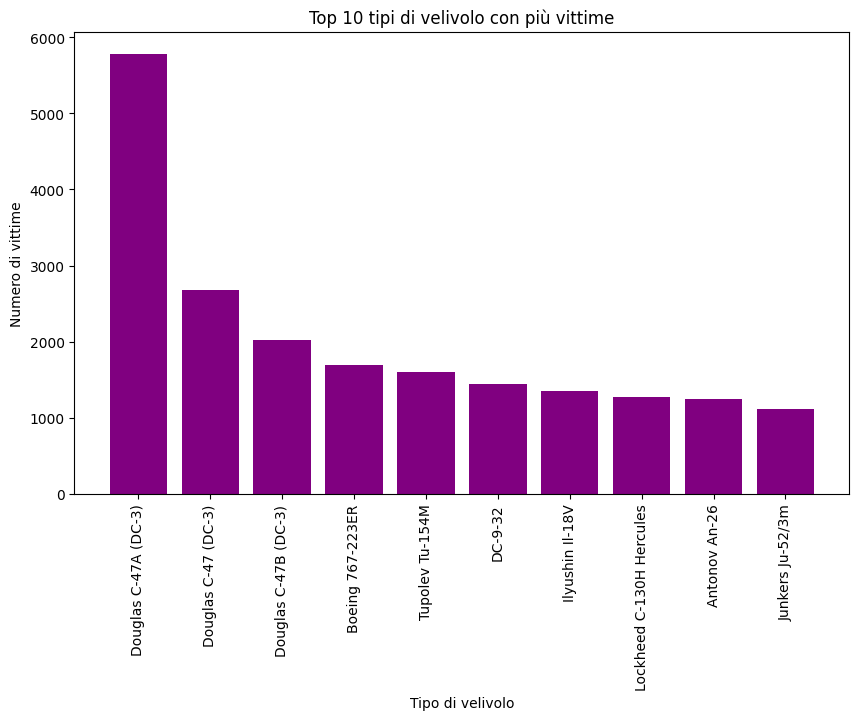

In [ ]:
# Calcolo del numero totale di vittime per velivolo
type_fatal = df.groupby("type")["fatalities"].sum()

# Rimozione valori nulli
type_fatal = type_fatal.dropna()

# Selezione dei 10 tipi di velivolo con più vittime
type_more_fatal = type_fatal.sort_values(ascending=False).head(10)

# Creazione grafico
plt.bar(type_more_fatal.index, type_more_fatal.values, color="purple")

plt.title("Top 10 tipi di velivolo con più vittime")
plt.xlabel("Tipo di velivolo")
plt.ylabel("Numero di vittime")
plt.xticks(rotation=90)

plt.show()

**Commento**: In base ai dati, la tipologia di velivolo che ha causato più vittime è il Douglas C-47 (primi 3 velivoli). Bisogna tenere presente che questo risultato è legato al suo impiego prolungato nel tempo e all'uso per lo più in contesti militari.

####**3.5 Analisi temporale della qualità delle informazioni registrate**

**_Come cambia la completezza dei dati nel tempo: Nazione sconosciuta e date incomplete_**

**Nota**: Il periodo della Seconda Guerra Mondiale presenta molte informazioni di Nazione sconosciuta, causando un picco estremamente elevato che rende difficile la lettura del trend generale. Per questo motivo la figura mostra un doppio grafico: il primo completo per mantenere l'integrità dei dati; il secondo con asse y limitato per evidenziare meglio le tendenze al di fuori del periodo di Guerra.

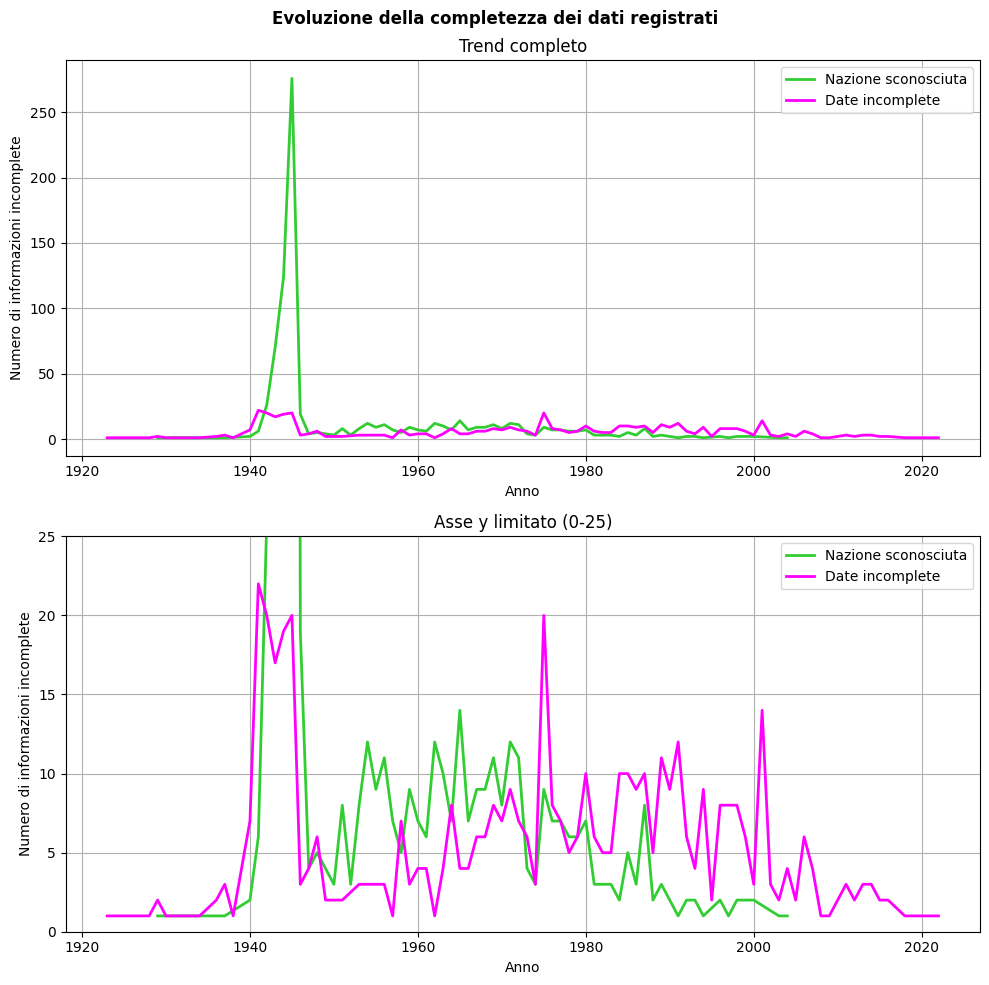

In [ ]:
# Conteggio annuale delle sole registrazioni "Unknown country"
unknown_per_year = df[df["country_clean"] == "Unknown country"].groupby("year").size()

# Conteggio annuale delle date incomplete
incomplete_dates = df[df["date"].isna()].groupby("year").size()

# Creazione della figura
plt.figure(figsize=(10, 10))
plt.suptitle("Evoluzione della completezza dei dati registrati", fontsize=12,
             fontweight="bold")

# Creazione del grafico con trend completo
plt.subplot(2, 1, 1)
plt.plot(unknown_per_year.index, unknown_per_year.values, label="Nazione sconosciuta",
         color="limegreen", linewidth=2)
plt.plot(incomplete_dates.index, incomplete_dates.values, label="Date incomplete",
         color="magenta", linewidth=2)

plt.title("Trend completo")
plt.xlabel("Anno")
plt.ylabel("Numero di informazioni incomplete")
plt.legend()
plt.grid()

# Creazione del grafico con asse y limitato
plt.subplot(2, 1, 2)
plt.plot(unknown_per_year.index, unknown_per_year.values, label="Nazione sconosciuta",
         color="limegreen", linewidth=2)
plt.plot(incomplete_dates.index, incomplete_dates.values, label="Date incomplete",
         color="magenta", linewidth=2)

plt.ylim(0, 25)

plt.title("Asse y limitato (0-25)")
plt.xlabel("Anno")
plt.ylabel("Numero di informazioni incomplete")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

**Commento**: I dati mostrano che le registrazioni con Nazione sconosciuta, dopo il picco degli anni della Seconda Guerra Mondiale, hanno un trend generale in diminuzione intorno agli anni '70 per poi sparire del tutto nei primi anni 2000.<br>
Le date incomplete, invece, non seguono un trend regolare: aumentano negli anni della Guerra, calano nei decenni successivi, tornano a crescere con un picco nella seconda metà degli anni '70 e rimangono molto irregolari fino ai primi anni 2000 in cui si nota una tendenza in diminuzione.<br>

In generale si può dire che negli ultimi anni sembra esserci un miglioramento complessivo della qualità e completezza delle registrazioni.<br>

Va comunque sottolineato che il numero di informazioni mancanti è molto basso rispetto al totale degli incidenti registrati, non alterando in modo significatvo le analisi complessive.